In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
url = 'https://github.com/LuizArmesto/notebooks/blob/master/regressao_linear/apartamentos_alugar_sao_paulo.csv?raw=true'

df = pd.read_csv(url)

df.head()

,valor,area,quartos,suites,vagas,bairro_id,bairro,cidade,tipo,subtipo,id
0,1600,57,2,0,1,1,VL DA SAUDE,Sao Paulo,1,3,9165861
1,5600,143,4,1,2,2,ITAIM BIBI,Sao Paulo,1,3,8657016
2,3000,140,3,1,1,3,BROOKLIN,Sao Paulo,1,2,9245580
3,4000,70,2,1,1,4,CAMPO BELO,Sao Paulo,1,2,8788916
4,2500,80,2,1,2,5,PERDIZES,Sao Paulo,1,1,9257792


In [3]:
df.shape

(28879, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28879 entries, 0 to 28878
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   valor      28879 non-null  int64 
 1   area       28879 non-null  int64 
 2   quartos    28879 non-null  int64 
 3   suites     28879 non-null  int64 
 4   vagas      28879 non-null  int64 
 5   bairro_id  28879 non-null  int64 
 6   bairro     28879 non-null  object
 7   cidade     28879 non-null  object
 8   tipo       28879 non-null  int64 
 9   subtipo    28879 non-null  int64 
 10  id         28879 non-null  int64 
dtypes: int64(9), object(2)
memory usage: 2.4+ MB


In [5]:
df.describe().round(2)

,valor,area,quartos,suites,vagas,bairro_id,tipo,subtipo,id
count,28879.00,28879.00,28879.00,28879.00,28879.00,28879.00,28879.0,28879.00,28879.00
mean,3482.07,98.54,2.34,0.88,1.65,46.37,1.0,1.98,8333660.53
std,2056.21,57.92,0.87,0.92,16.25,58.71,0.0,1.18,1544808.58
min,500.00,0.00,0.00,0.00,0.00,1.00,1.0,1.00,45429.00
25%,2000.00,60.00,2.00,0.00,1.00,10.00,1.0,1.00,7766744.50
50%,2800.00,80.00,2.00,1.00,1.00,29.00,1.0,2.00,8929920.00
75%,4500.00,123.00,3.00,1.00,2.00,56.00,1.0,2.00,9383485.00
max,10000.00,694.00,8.00,5.00,2000.00,449.00,1.0,4.00,9645240.00


In [6]:
print(df.isna().sum())

valor        0
area         0
quartos      0
suites       0
vagas        0
bairro_id    0
bairro       0
cidade       0
tipo         0
subtipo      0
id           0
dtype: int64


In [7]:
print(df.value_counts('area'))

area
70     1289
60      995
50      894
65      797
80      697
       ... 
412       1
420       1
418       1
421       1
450       1
Name: count, Length: 368, dtype: int64


In [8]:
# Filtra imóveis com área <= 20
area_pqn = df[df['area'] <= 20]
area_pqn.head(3)

,valor,area,quartos,suites,vagas,bairro_id,bairro,cidade,tipo,subtipo,id
4020,1400,19,2,0,0,240,VL STA MARIA,Sao Paulo,1,1,9254309
4806,750,15,2,0,1,261,GUAIANAZES,Sao Paulo,1,1,9143698
5487,1350,18,1,1,0,37,VL MARIANA,Sao Paulo,1,2,7062438


In [9]:
print(area_pqn['area'].value_counts())

area
0     23
10     7
15     6
20     6
19     1
18     1
1      1
Name: count, dtype: int64


In [10]:
# Ajusta áreas muito pequenas (<= 20) substituindo pela moda da área por valor ou pela mediana geral
for valor_unico in df['valor'].unique():
    grupo = df[df['valor'] == valor_unico]
    moda_area = grupo['area'].mode()

    if not moda_area.empty and moda_area[0] > 20:
        novo_valor = moda_area[0]
    else:
        novo_valor = df['area'].median()

    df.loc[(df['valor'] == valor_unico) & (df['area'] <= 20), 'area'] = novo_valor

In [11]:
# Verifica se ainda existem registros com área <= 20 após a correção
print(df[df['area'] <= 20])

Empty DataFrame
Columns: [valor, area, quartos, suites, vagas, bairro_id, bairro, cidade, tipo, subtipo, id]
Index: []


In [12]:
# Verifica se existem registros com zero quartos
df[df['quartos'] == 0]

,valor,area,quartos,suites,vagas,bairro_id,bairro,cidade,tipo,subtipo,id
3758,2500,122,0,0,0,110,VL STA CATARINA,Sao Paulo,1,1,8680004
6743,2670,45,0,0,0,41,JARDINS,Sao Paulo,1,1,7801228
8279,8500,180,0,0,0,41,JARDINS,Sao Paulo,1,1,9624989
17889,2400,100,0,0,2,16,MOOCA,Sao Paulo,1,1,9587770
18997,700,30,0,0,0,42,BELA VISTA,Sao Paulo,1,1,9576508
21225,8000,138,0,0,2,3,BROOKLIN,Sao Paulo,1,1,9067825
22120,800,40,0,0,0,51,STA CECÍLIA,Sao Paulo,1,1,9610085
22727,2800,113,0,0,0,49,HIGIENÓPOLIS,Sao Paulo,1,1,7806634


In [13]:
# Substitui quartos iguais a 0 pela moda de quartos para cada área
for valor_area in df['area'].unique():
    grupo_area = df[df['area'] == valor_area]
    moda_quartos = grupo_area['quartos'].mode()

    if not moda_quartos.empty:
        # Substitui os quartos iguais a 0 pela moda dos quartos daquela área
        df.loc[(df['area'] == valor_area) & (df['quartos'] == 0), 'quartos'] = moda_quartos[0]

In [14]:
# Verifica a correção dos valores de quartos em registros específicos
df.iloc[[21225, 22120, 22727]]

,valor,area,quartos,suites,vagas,bairro_id,bairro,cidade,tipo,subtipo,id
21225,8000,138,3,0,2,3,BROOKLIN,Sao Paulo,1,1,9067825
22120,800,40,1,0,0,51,STA CECÍLIA,Sao Paulo,1,1,9610085
22727,2800,113,3,0,0,49,HIGIENÓPOLIS,Sao Paulo,1,1,7806634


In [15]:
# Verifica imóveis com área >= 100 e sem suítes
df[(df['area'] >= 100) & (df['suites'] == 0)]

,valor,area,quartos,suites,vagas,bairro_id,bairro,cidade,tipo,subtipo,id
5,3200,110,2,0,0,6,JD PAULISTA,Sao Paulo,1,2,9196536
35,3000,112,2,0,0,23,CERQUEIRA CÉSAR,Sao Paulo,1,2,5590028
85,4000,180,3,0,1,23,CERQUEIRA CÉSAR,Sao Paulo,1,1,9061887
98,4500,231,4,0,2,41,JARDINS,Sao Paulo,1,3,8600379
207,2300,129,2,0,2,37,VL MARIANA,Sao Paulo,1,1,9157788
...,...,...,...,...,...,...,...,...,...,...,...
28765,5000,123,3,0,1,6,JD PAULISTA,Sao Paulo,1,2,7446125
28767,6500,160,3,0,1,6,JD PAULISTA,Sao Paulo,1,2,7581900
28821,6000,120,2,0,2,42,BELA VISTA,Sao Paulo,1,1,8518577
28837,5000,103,3,0,1,12,VL OLÍMPIA,Sao Paulo,1,1,7367603


In [16]:
# Substitui suítes iguais a 0 pela moda por área ou pela mediana geral
for valor_area in df['area'].unique():
    grupo_area = df[df['area'] == valor_area]
    moda_suites = grupo_area['suites'].mode()

    if not moda_suites.empty and moda_suites[0] == 0:
      novo_valor = moda_suites[0]

    else:
      novo_valor = df['suites'].median()

    df.loc[(df['area'] == valor_area) & (df['suites'] == 0), 'suites'] = novo_valor

In [17]:
# Verifica a correção dos valores de suites em registros específicos
df.iloc[[ 28869, 28837, 28821]]

,valor,area,quartos,suites,vagas,bairro_id,bairro,cidade,tipo,subtipo,id
28869,3100,100,2,1,1,10,MOEMA,Sao Paulo,1,4,9031478
28837,5000,103,3,1,1,12,VL OLÍMPIA,Sao Paulo,1,1,7367603
28821,6000,120,2,1,2,42,BELA VISTA,Sao Paulo,1,1,8518577


In [18]:
# Filtra imóveis com área >= 100 e sem suítes
df[(df['area'] >= 100) & (df['suites'] == 0)]

,valor,area,quartos,suites,vagas,bairro_id,bairro,cidade,tipo,subtipo,id
3708,6000,370,4,0,3,49,HIGIENÓPOLIS,Sao Paulo,1,2,8518219
9489,6500,385,3,0,3,37,VL MARIANA,Sao Paulo,1,1,8972399
20731,5000,370,4,0,2,42,BELA VISTA,Sao Paulo,1,2,9631834
21570,7500,259,3,0,2,49,HIGIENÓPOLIS,Sao Paulo,1,1,4563599


In [19]:
# Substitui valores de 'suites' iguais a 0 pela mediana, para imóveis com área >= 259
df.loc[(df['area'] >= 259) & (df['suites'] == 0), 'suites'] = df['suites'].median()

In [20]:
# Verifica registros com índices inconsistentes após as transformações
df.iloc[[ 21570, 20731, 9489, 3708]]

,valor,area,quartos,suites,vagas,bairro_id,bairro,cidade,tipo,subtipo,id
21570,7500,259,3,1,2,49,HIGIENÓPOLIS,Sao Paulo,1,1,4563599
20731,5000,370,4,1,2,42,BELA VISTA,Sao Paulo,1,2,9631834
9489,6500,385,3,1,3,37,VL MARIANA,Sao Paulo,1,1,8972399
3708,6000,370,4,1,3,49,HIGIENÓPOLIS,Sao Paulo,1,2,8518219


In [21]:
# Engenharia de features:
# Cria novas variáveis derivadas: preço por m² e total de banheiros
df['preco_m2'] = round(df['valor'] / df['area'], 2)
df['banheiros']  = df['suites'] +1

In [22]:
df.sample(3)

,valor,area,quartos,suites,vagas,bairro_id,bairro,cidade,tipo,subtipo,id,preco_m2,banheiros
26644,3000,95,3,2,2,60,SANTANA,Sao Paulo,1,2,9356656,31.58,3
6136,2000,70,2,0,0,42,BELA VISTA,Sao Paulo,1,2,8900151,28.57,1
2590,2500,90,3,1,2,206,JD DA GLÓRIA,Sao Paulo,1,2,8880854,27.78,2


## 📊 Análise Exploratória dos Dados

Nesta seção, serão apresentados alguns gráficos para visualizar padrões e relações entre as variáveis do dataset.

In [24]:
# Calcula o preço médio por m² por bairro
media_m2_bairro = (
    df.groupby('bairro')
    .filter(lambda x: len(x) >= df['bairro'].value_counts().iloc[99])
    .groupby('bairro')['preco_m2']
    .mean()
    .round(2)
)

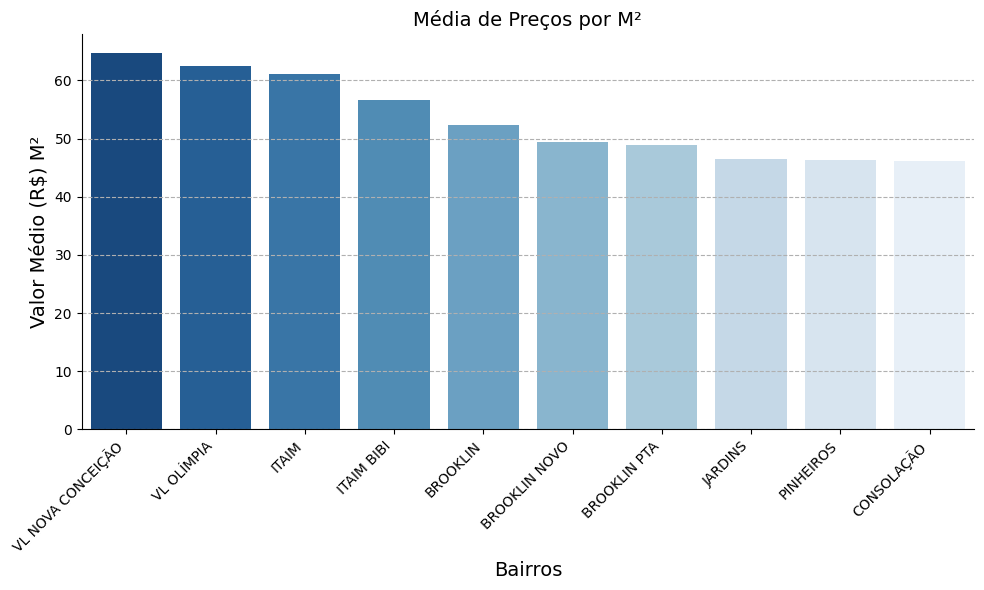

In [26]:
# Seleciona os 10 bairros com maior preço médio por m² e cria um gráfico de barras
top10 = media_m2_bairro.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top10.index,
    y=top10.values,
    palette='Blues_r'
)

plt.title('Média de Preços por M²', fontsize=14)
plt.xlabel('Bairros',fontsize=14)
plt.ylabel('Valor Médio (R$) M²', fontsize=14)
plt.xticks(rotation=45, ha='right')
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

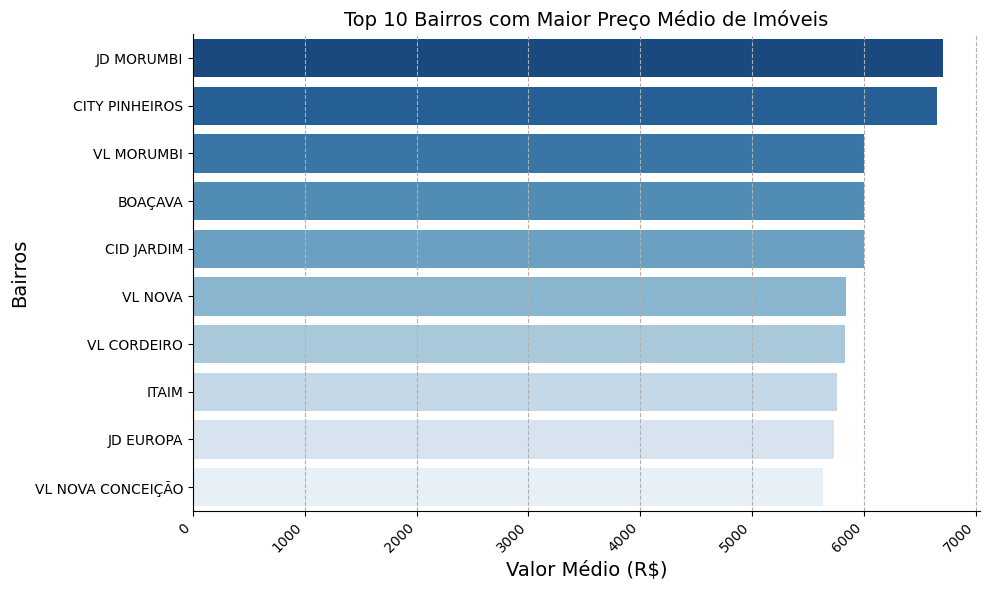

In [29]:
# Calcula e visualiza os 10 bairros com maior valor médio de imóveis em São Paulo
plt.figure(figsize=(10, 6))
media_bairros = df.groupby('bairro')['valor'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=media_bairros.values, y=media_bairros.index, palette='Blues_r')

plt.title('Top 10 Bairros com Maior Preço Médio de Imóveis', fontsize=14)
plt.xlabel('Valor Médio (R$)', fontsize=14)
plt.ylabel('Bairros', fontsize=14)
plt.xticks(rotation=45, ha='right')
sns.despine(top=True, right=True)
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

### 📌 Insight

Os bairros apresentados concentram os maiores valores médios de imóveis, indicando regiões com maior valorização imobiliária.
Esses resultados sugerem a presença de infraestrutura diferenciada, localização privilegiada e maior demanda por imóveis de alto padrão.

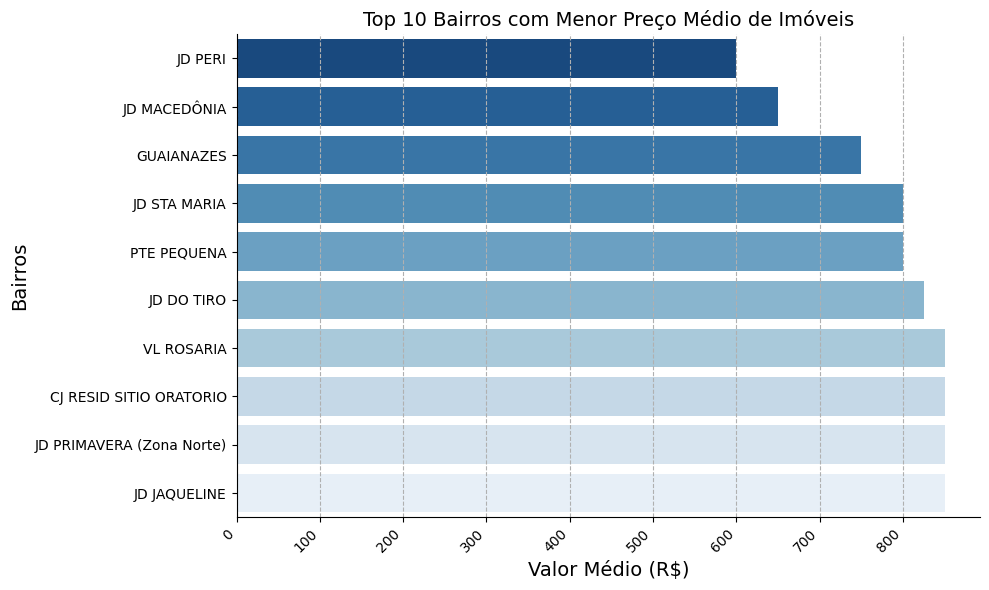

In [30]:
# Calcula e visualiza os 10 bairros com menor valor médio de imóveis em São Paulo
plt.figure(figsize=(10, 6))
media_bairros = df.groupby('bairro')['valor'].mean().sort_values(ascending=True).head(10)

sns.barplot(x=media_bairros.values, y=media_bairros.index, palette='Blues_r')

plt.title('Top 10 Bairros com Menor Preço Médio de Imóveis', fontsize=14)
plt.xlabel('Valor Médio (R$)', fontsize=14)
plt.ylabel('Bairros', fontsize=14)
plt.xticks(rotation=45, ha='right')
sns.despine(top=True, right=True)
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

### 📌 Insight

Os bairros com menor preço médio de imóveis representam regiões mais acessíveis do mercado imobiliário, com valores significativamente abaixo da média geral do dataset.

Esse comportamento pode estar associado a fatores como localização periférica, menor oferta de infraestrutura urbana e menor demanda por imóveis de alto padrão.

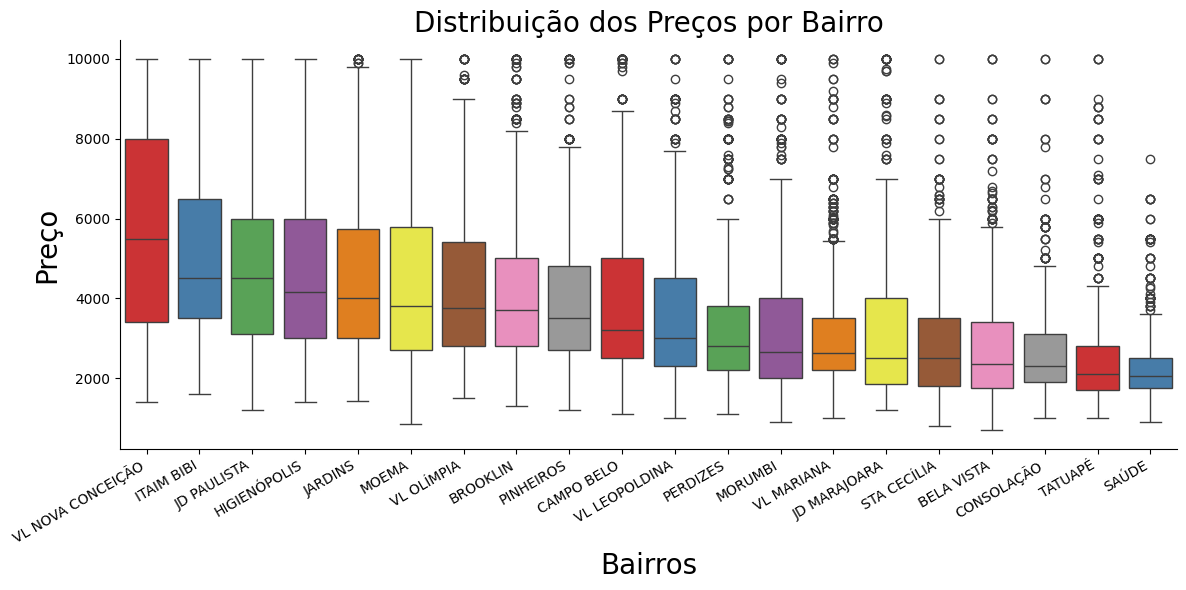

In [31]:
# Seleciona os 20 bairros mais frequentes no dataset e filtra os dados
# Em seguida, visualiza a distribuição dos preços por bairro usando boxplot
top_bairros = df['bairro'].value_counts().nlargest(20).index
df_top = df[df['bairro'].isin(top_bairros)]

plt.figure(figsize=(12, 6))

# Ordena os bairros pela mediana do preço para melhor comparação visual
order = df_top.groupby('bairro')['valor'].median().sort_values(ascending=False).index

sns.boxplot(data=df_top, x='bairro', y='valor', order=order, palette='Set1')

plt.title('Distribuição dos Preços por Bairro', fontsize=20)
plt.ylabel('Preço', fontsize=20)
plt.xlabel('Bairros', fontsize=20)
plt.xticks(rotation=30, ha='right', fontsize=10)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

In [33]:
idx_min = df['valor'].idxmin()
idx_max = df['valor'].idxmax()
x0 = df['valor'][idx_min]
y0 = df['area'][idx_min]
x1 = df['valor'][idx_max]
y1 = df['area'][idx_max]

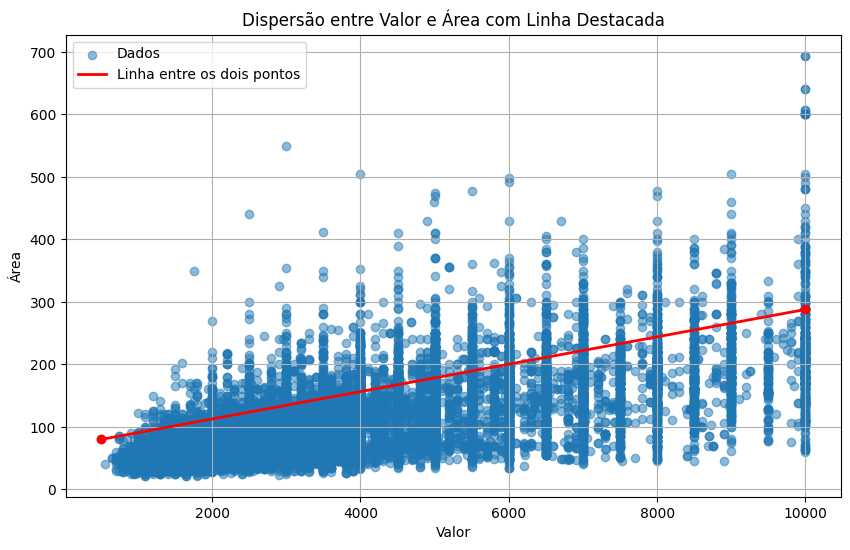

In [34]:
# Cria um gráfico de dispersão entre valor e área dos imóveis
# e destaca uma linha entre dois pontos específicos selecionados manualmente
plt.figure(figsize=(10, 6))
plt.scatter(df['valor'], df['area'], alpha=0.5, label='Dados')

plt.plot([x0, x1], [y0, y1], 'r-', linewidth=2, label='Linha entre os dois pontos')
plt.scatter([x0, x1], [y0, y1], color='red', zorder=5)

plt.xlabel('Valor')
plt.ylabel('Área')
plt.title('Dispersão entre Valor e Área com Linha Destacada')
plt.legend()
plt.grid(True)
plt.show()

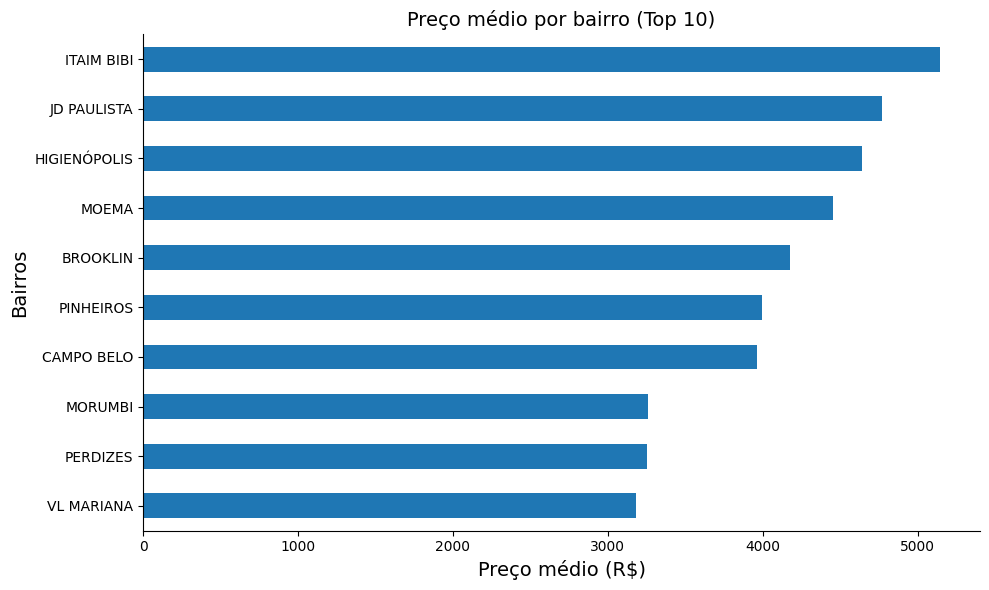

In [35]:
# Filtra os 10 bairros mais frequentes no dataset
# e calcula o preço médio dos imóveis nesses bairros
# O resultado é visualizado em um gráfico de barras horizontal para facilitar a comparação
top_bairros = df['bairro'].value_counts().head(10).index
media_preco_top = df.groupby('bairro')['valor'].mean().loc[top_bairros]

ax = media_preco_top.sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

ax.set_title('Preço médio por bairro (Top 10)', fontsize=14)
ax.set_xlabel('Preço médio (R$)', fontsize=14)
ax.set_ylabel('Bairros', fontsize=14)
sns.despine(right= True, top= True)

plt.tight_layout()
plt.show()

## 🤖 Machine Learning

Nesta etapa, será iniciado o processo de modelagem utilizando técnicas de Machine Learning para prever e analisar padrões nos dados.

In [36]:
X = df.drop(columns=['id', 'bairro_id', 'tipo', 'subtipo', 'cidade', 'valor', 'preco_m2'])
y = df['valor']

In [37]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.3)

In [38]:
obj_cols = X.select_dtypes(include='object').columns.tolist()

In [39]:
num_cols = []

for col in X.columns:
  if X[col].dtype != 'object':
    num_cols.append(col)

print(num_cols)

['area', 'quartos', 'suites', 'vagas', 'banheiros']


In [40]:
preprocess = ColumnTransformer(transformers=[
                ('OneHot', OneHotEncoder(handle_unknown='ignore'), obj_cols),
                ('Scaler', StandardScaler(), num_cols)],
                remainder='drop'

            )

In [41]:
models = {
    'Decision Tree': DecisionTreeRegressor(),
    'Linear Regression': LinearRegression(),
    'XGBoost': XGBRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'KNN': KNeighborsRegressor()
}

In [42]:
for name, reg in models.items():

  model = Pipeline(steps=[
      ('Preprocess', preprocess),
      ('Model', reg)
  ])

  model.fit(X_train, y_train)
  y_pred = model.predict(X_val)

  mae = mean_absolute_error(y_val, y_pred)

  print(f'{name}: {mae:.2f}')

Decision Tree: 722.24
Linear Regression: 840.15
XGBoost: 703.35
Gradient Boosting: 802.12
KNN: 735.33


### 📊 Avaliação dos Modelos

A avaliação dos modelos de regressão foi realizada com base em uma métrica de erro.

O XGBoost apresentou o melhor desempenho, obtendo o menor erro entre os modelos testados, sendo assim selecionado para as próximas etapas do projeto.

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint


xgb = XGBRegressor(random_state=42)

param_dist = {
    'n_estimators': randint(50, 300, 500),
    'max_depth': randint(3, 6, 9),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
}


scoring = {
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring=scoring,
    refit='MAE',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)


model_xgb = Pipeline(steps=[
    ('Preprocess', preprocess),
    ('Model', random_search)
])


model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_val)


mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2%}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
MAE: 653.23
RMSE: 980.86
R²: 76.99%


In [51]:
# Avaliação final do modelo no conjunto de teste
# O modelo realiza previsões em dados nunca vistos durante o treinamento,
# permitindo uma avaliação mais realista da sua capacidade de generalização

# Métricas utilizadas:
# - MAE: erro absoluto médio
# - RMSE: raiz do erro quadrático médio
# - R²: coeficiente de determinação

y_pred = model_xgb.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Avaliação final do modelo no conjunto de teste')
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2%}')

Avaliação final do modelo no conjunto de teste
MAE: 673.29
RMSE: 980.86
R²: 75.94%


## 📊 Resultados Finais do Modelo

Após o treinamento e otimização do modelo XGBoost com RandomizedSearchCV, realizamos a avaliação final nos dados de teste.

Para facilitar a análise dos resultados, foi criado um dataframe comparando os valores reais dos imóveis com as previsões do modelo, além do erro absoluto de cada previsão.

Essa etapa permite visualizar, de forma prática, o desempenho do modelo em cenários reais e entender o nível de precisão das estimativas.

In [49]:
df_resultados = pd.DataFrame({
    'Preço Real (R$)': y_test.values,
    'Preço Previsto (R$)': y_pred
})

df_resultados['Erro Absoluto (R$)'] = abs(df_resultados['Preço Real (R$)'] - df_resultados['Preço Previsto (R$)'])
df_resultados = df_resultados.round(0).astype(int)
df_resultados.sample(10)

,Preço Real (R$),Preço Previsto (R$),Erro Absoluto (R$)
1530,1500,1515,15
79,9500,9280,220
1209,4200,3746,454
1761,2450,2601,151
124,4200,2565,1635
2298,2200,2426,226
266,2500,2798,298
1946,6000,3964,2036
1500,6000,6772,772
1239,6000,6876,876
